# Differentiable Ultrasound from MRI: GPU Speed Test

We run 100 simulations of different ray lengths and size to measure the execution time.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import os

import sys
import pathlib

PROJECT_ROOT = pathlib.Path().cwd().parent
sys.path.append(str(PROJECT_ROOT))

image_path = PROJECT_ROOT / 'ReMIND2Reg_dataset' / 'imagesTr'

from src.utils import *
from src.impedance import *
from src.renderer_clean import *
from src.cone import *

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
# =====================
# Academic Plot Settings
# =====================
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Palatino', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'axes.linewidth': 1.2,
    'grid.color': '0.8',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'figure.figsize': (7, 5),
    'figure.autolayout': True,
    'mathtext.fontset': 'stix'
})

In [3]:
assert torch.cuda.is_available(), "CUDA is not available. Please check your PyTorch installation."

### MLP - Importing the pre computed model

In [4]:
model = torch.load('./MLP/impedance_estimator.pth', weights_only=False)
model.eval();
model = model.to('cuda')

## Opening the files

In [5]:
import sys
import pathlib

PROJECT_ROOT = pathlib.Path().cwd().parent
sys.path.append(str(PROJECT_ROOT))

image_path = PROJECT_ROOT / 'ReMIND2Reg_dataset' / 'imagesTr'

from src.utils import *
from src.impedance import *
from src.renderer_clean import *
from src.cone import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import torch

In [6]:
t1_file = \
    r"C:\Users\noe\Desktop\MIT\6.8300\project\DiffUS_DifferentiableUltrasoundfromMRI\additional_data\Reuben\Case103-cet1.nii.gz"
iUS_file= \
    r"C:\Users\noe\Desktop\MIT\6.8300\project\DiffUS_DifferentiableUltrasoundfromMRI\additional_data\Reuben\Case103-us.nii.gz"

# Load with nibabel; each img is a Nifti1Image object
us_img = nib.load(str(image_path / iUS_file))
t1_img = nib.load(str(image_path / t1_file))

# Extract data arrays (as NumPy) and affines
US_vol = us_img.get_fdata(dtype=np.float32)
US_affine = us_img.affine
T1_vol = t1_img.get_fdata(dtype=np.float32)
T1_affine = t1_img.affine

T1_vol_tensor = torch.tensor(T1_vol, dtype=torch.float32, device='cuda') 
T1_flat = T1_vol_tensor.flatten().unsqueeze(1)  # shape (N, 1)

with torch.no_grad():
    Z_flat = model(T1_flat).squeeze() * 1e6  # shape (N,)

Z_vol = Z_flat.reshape(T1_vol_tensor.shape)

# Preliminary computations

We start by choosing a view of the ultrasound for this speed test

In [7]:
i_mri, j_mri, k_mri = 150, 100, 70
us_slice, us_idx = mri_to_us_point(
    i_mri, 
    j_mri, 
    k_mri, 
    T1_vol, 
    T1_affine, 
    US_vol,
    US_affine)
mL, bL = -0.61, 83  # Left edge line parameters (slope, intercept)
mR, bR = 0.67, 113  # Right edge line parameters (slope, intercept)
i_us, j_us, k_us = us_idx
H_us, W_us = us_slice.shape
cone_params = compute_us_apex_and_direction(mL, bL, mR, bR)
x0, y0 = cone_params["apex"]
opening_angle   = cone_params["opening_angle"]
direction_vec   = cone_params["direction_vector"][::-1]
d1, d2 = plot_median_line(
    us_slice,
    cone_params["apex"],  # (x0, y0)
    direction_vec,
)

t1_slice = T1_vol[:, :, k_mri]
apex_us_vox = np.array([x0, y0, k_us])  # (x, y, z) in voxel space

# Convert apex and direction to MRI world coordinates
apex_mri_world, direction_mri_world = cone_us_to_mri_world(
    apex_us_vox,
    direction_vec,
    US_affine,
    T1_affine
)
print(apex_mri_world, direction_mri_world)
# For MRI, apex and direction are in (row, col) = (y, x) order

[-23.4375    97.296875  70.      ] [ 0.99977352 -0.02128176]
Error in callback <function flush_figures at 0x0000028E09C928E0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

# GPU Run


In [ ]:
H,W = us_slice.shape
source = torch.tensor(apex_mri_world, device='cuda') 


In [ ]:
for n_rays in [64, 64, 128, 256]:
    directions = generate_cone_directions(direction_mri_world[::-1], opening_angle/2, n_rays)
    directions = directions.to('cuda')

    for n_depth in [32, 70, 100, 200]:    
        print(f"Running with n_rays={n_rays}, n_depth={n_depth}")
        total_t = 0
        for _ in range(10):
            start_time = time.time()
            renderer = UltrasoundRenderer(num_samples=n_depth, attenuation_coeff=0.0001)
        
            _ = renderer.render_us_frame(
                        volume=Z_vol,
                        source=source[[1,0,2]],
                        directions=directions,
                        angle=np.degrees(opening_angle)/2-5,
                        plot=False,
                        artifacts=False,
                        start=0,  # Adjusted start to match the cone segment,
                        str_radial = 0.02,
                        std_local = 0.2,

                    )
            run_time = time.time() - start_time
            total_t += run_time
        print(f"Average time for n_rays={n_rays}, n_depth={n_depth}: {total_t / 10:.4f} seconds")

Running with n_rays=64, n_depth=32


c:\Users\noe\anaconda3\envs\torchIO\Lib\site-packages\torch\nn\functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


Average time for n_rays=64, n_depth=32: 0.1376 seconds
Running with n_rays=64, n_depth=70
Average time for n_rays=64, n_depth=70: 0.4650 seconds
Running with n_rays=64, n_depth=100
Average time for n_rays=64, n_depth=100: 0.9347 seconds
Running with n_rays=64, n_depth=200
Average time for n_rays=64, n_depth=200: 3.7177 seconds
Running with n_rays=64, n_depth=32
Average time for n_rays=64, n_depth=32: 0.0997 seconds
Running with n_rays=64, n_depth=70
Average time for n_rays=64, n_depth=70: 0.4373 seconds
Running with n_rays=64, n_depth=100
Average time for n_rays=64, n_depth=100: 0.9025 seconds
Running with n_rays=64, n_depth=200
Average time for n_rays=64, n_depth=200: 4.2892 seconds
Running with n_rays=128, n_depth=32
Average time for n_rays=128, n_depth=32: 0.1508 seconds
Running with n_rays=128, n_depth=70
Average time for n_rays=128, n_depth=70: 0.6934 seconds
Running with n_rays=128, n_depth=100
Average time for n_rays=128, n_depth=100: 1.3493 seconds
Running with n_rays=128, n_de

KeyboardInterrupt: 

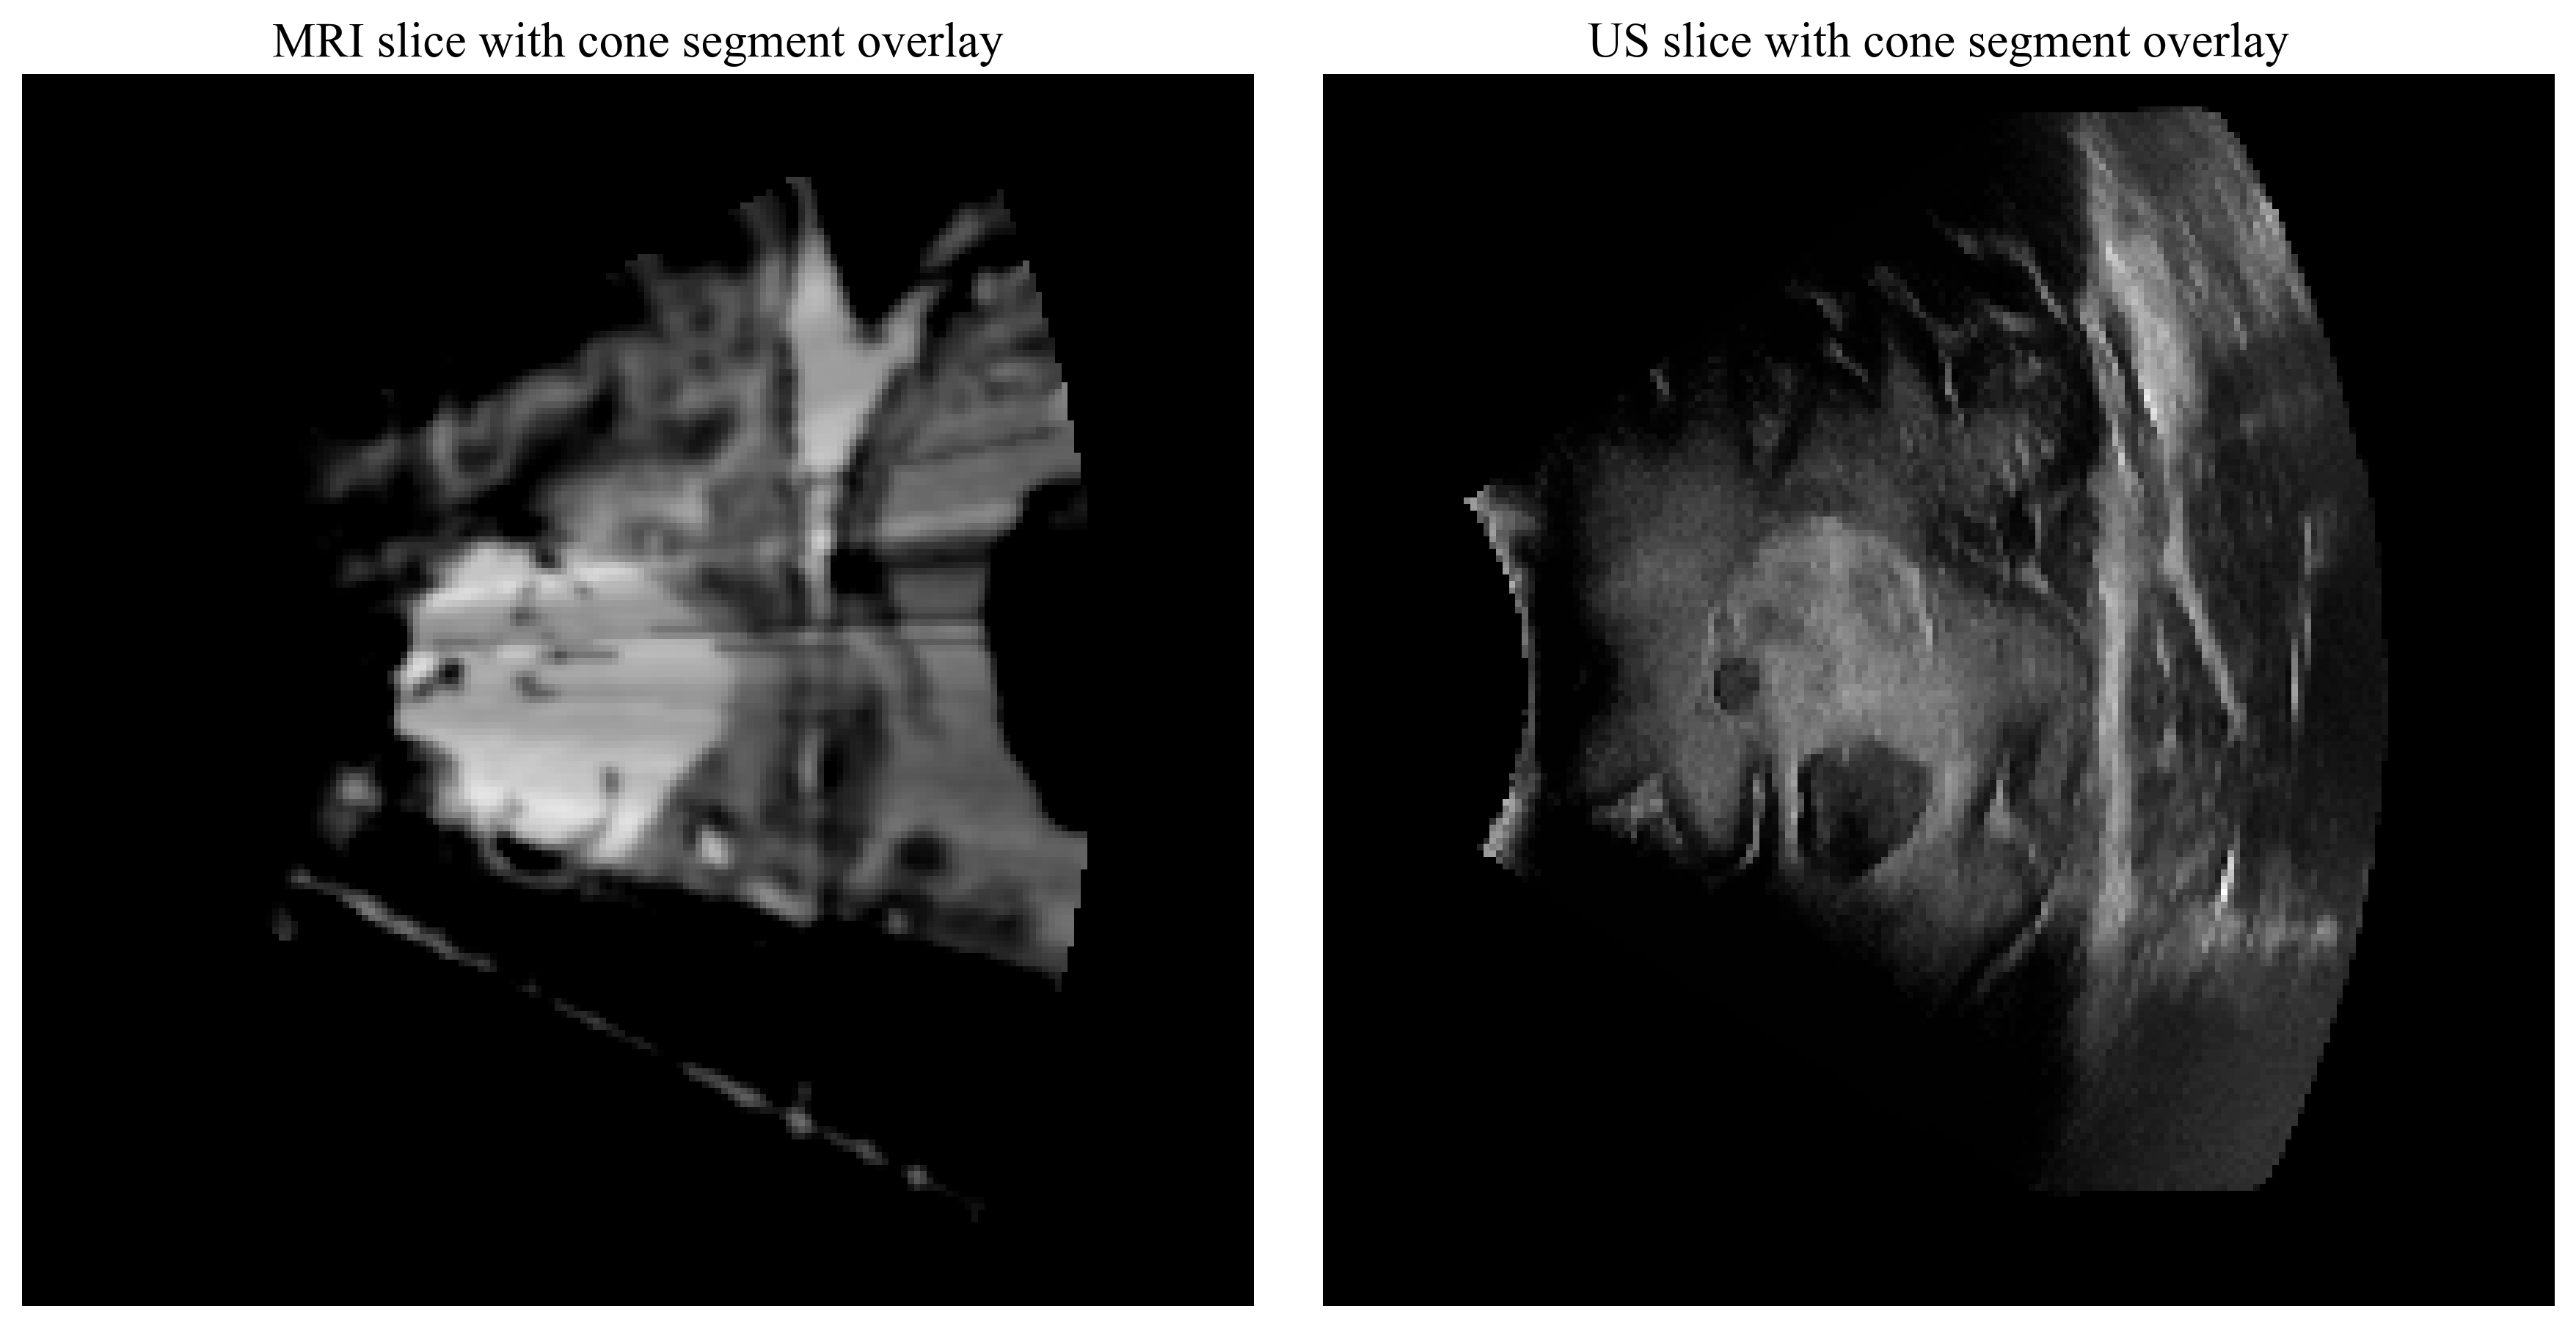

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(output.detach().cpu(), cmap='gray', origin='lower', vmin=0, vmax=0.5)
axs[0].set_title("MRI slice with cone segment overlay")
axs[0].axis('off')
axs[1].imshow(us_slice, cmap='gray', origin='lower')
axs[1].set_title("US slice with cone segment overlay")
axs[1].axis('off')
plt.tight_layout()
plt.show()

C:\Users\noe\AppData\Local\Temp\ipykernel_30708\3976785391.py:12: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



[INFO] Visualizing sampled points in 3D volume
[INFO] Variances: x=947.4326, y=2511.1035, z=0.0000
(1, 1, 192, 156)


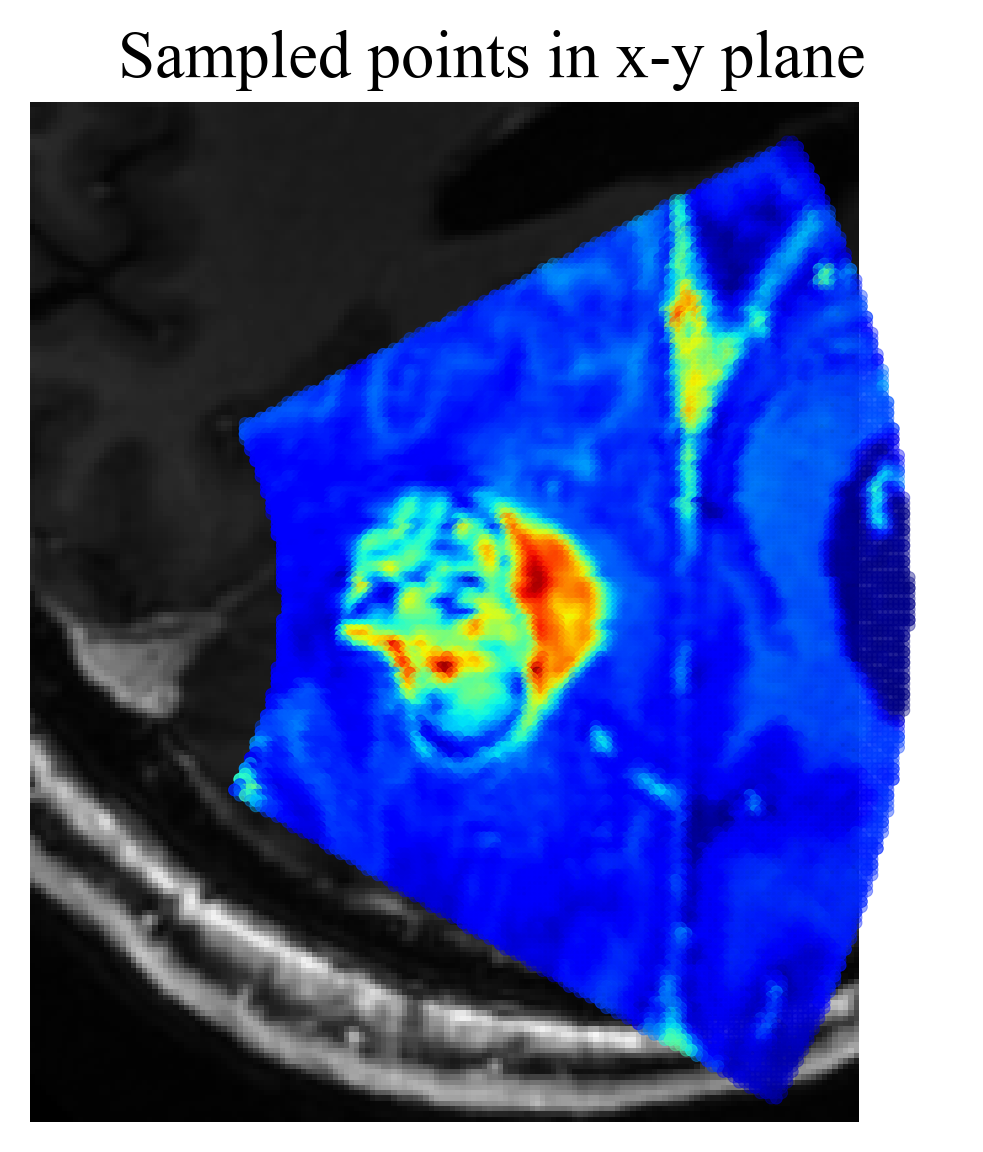

tensor(0.) tensor(1.1068)


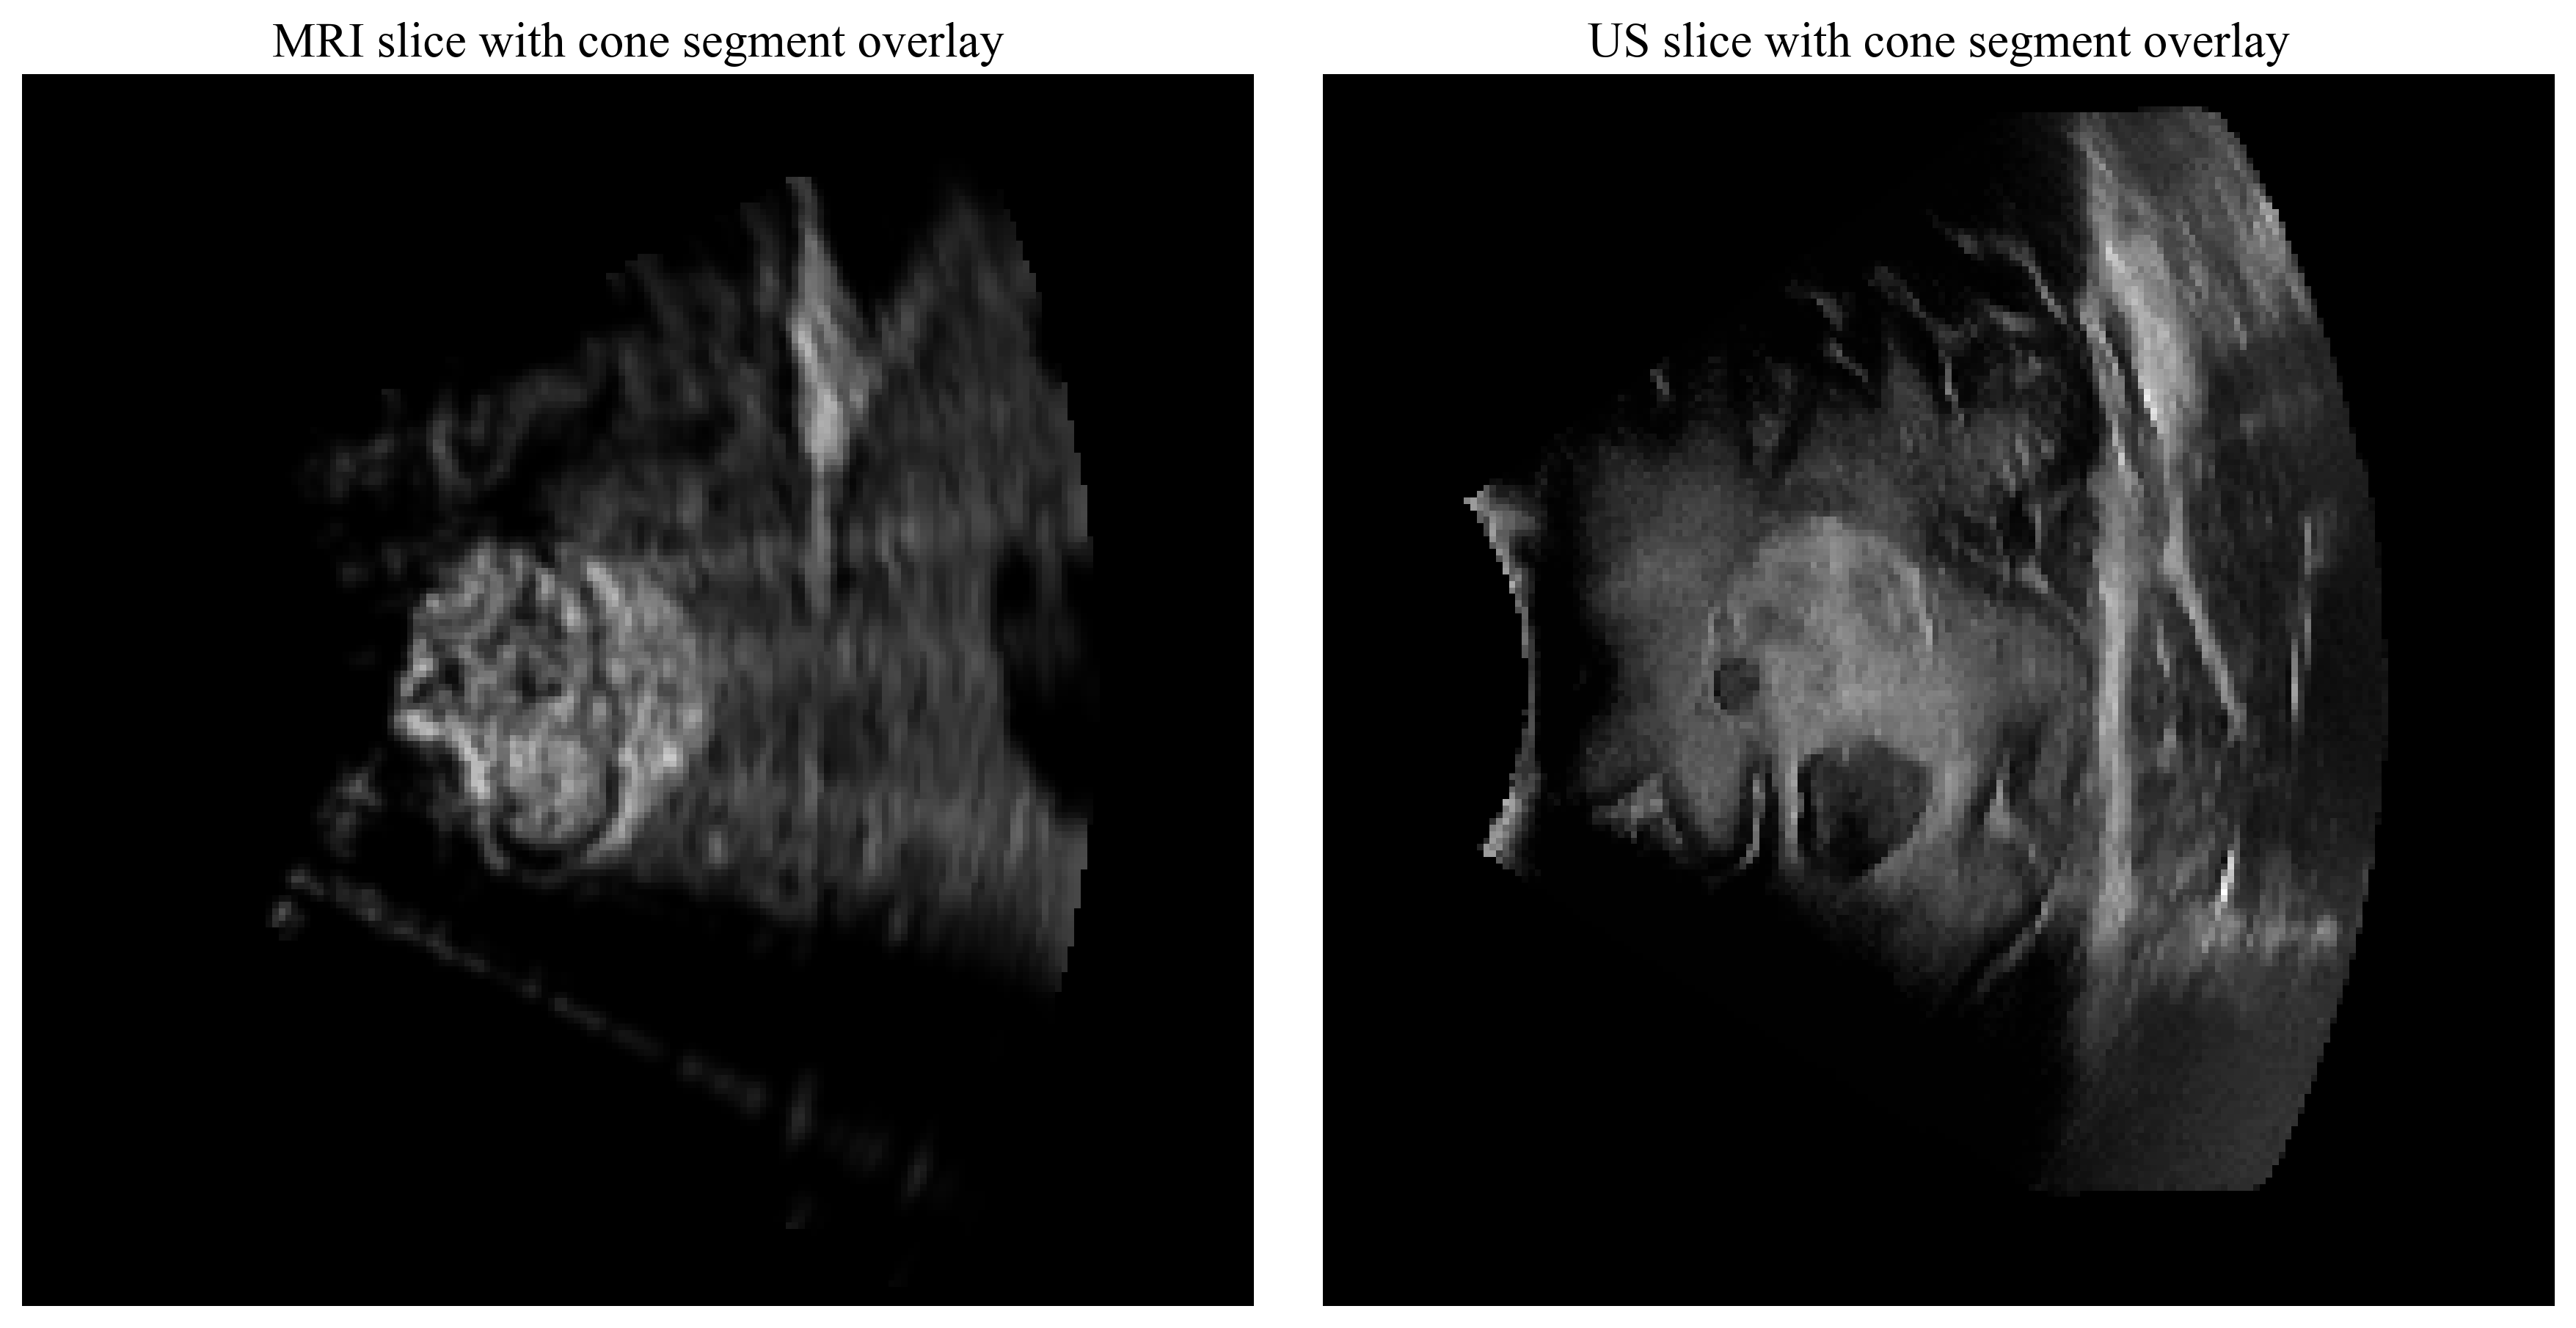

In [ ]:
H,W = us_slice.shape
renderer = UltrasoundRenderer(num_samples=d2, attenuation_coeff=0.0001)


# Geometric parameters for the cone segment
n_rays = 256
source = torch.tensor(apex_mri_world)
directions = generate_cone_directions(direction_mri_world[::-1], opening_angle/2, n_rays)

# Simulation
x,y,z, intensities = renderer.render_us_frame(
            volume=torch.tensor(Z_vol),
            source=source[[1,0,2]],
            directions=directions,
            angle=np.degrees(opening_angle)/2-5,
            plot=True,
            artifacts=True,
            start=d1,  # Adjusted start to match the cone segment,
            str_radial = 0.02,
            std_local = 0.2,

        )
output = differentiable_splat(x, 
                     y,
                     z, 
                     intensities, 
                     H=H, 
                     W=W, 
                     sigma=0.8)
print(output.min(), output.max())
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(output, cmap='gray', origin='lower', vmin=0, vmax=1.4)
axs[0].set_title("MRI slice with cone segment overlay")
axs[0].axis('off')
axs[1].imshow(us_slice, cmap='gray', origin='lower')
axs[1].set_title("US slice with cone segment overlay")
axs[1].axis('off')
plt.tight_layout()
plt.show()